Daily Challenge — Classification avec TensorFlow


 TYPES DE CLASSIFICATION :

1. Binaire    → 2 classes (0 ou 1)
               Ex: Spam/Pas spam
               Loss: binary_crossentropy
               Activation sortie: sigmoid

2. Multi-class → N classes, une seule vraie
               Ex: MNIST (0 à 9)
               Loss: categorical_crossentropy
               Activation sortie: softmax

3. Multi-label → N classes, plusieurs vraies
               Ex: Tags d'un article (sport ET politique)
               Loss: binary_crossentropy sur chaque label
               Activation sortie: sigmoid par neurone

X shape : (1000, 2)
y shape : (1000,)
Classes : [0 1]


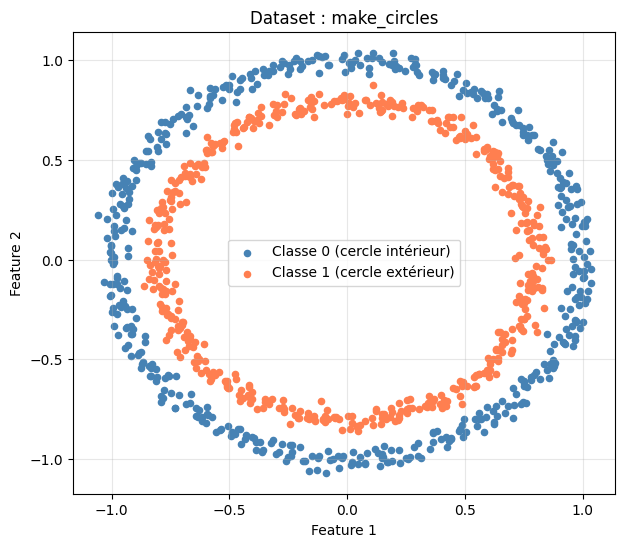


Train : 800 exemples
Test  : 200 exemples

 MODÈLE BASIQUE (1 couche)
Précision basique : 48.50%


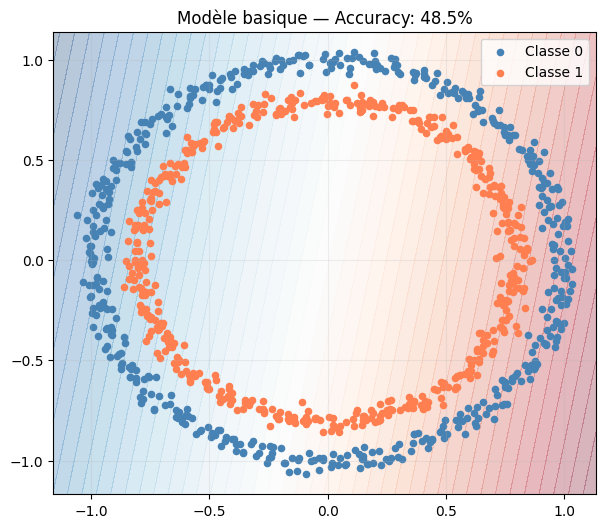


 MODÈLE AMÉLIORÉ
Précision améliorée : 100.00%


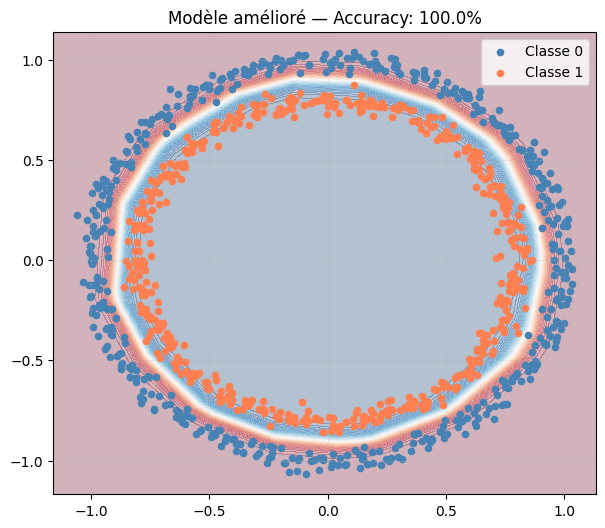

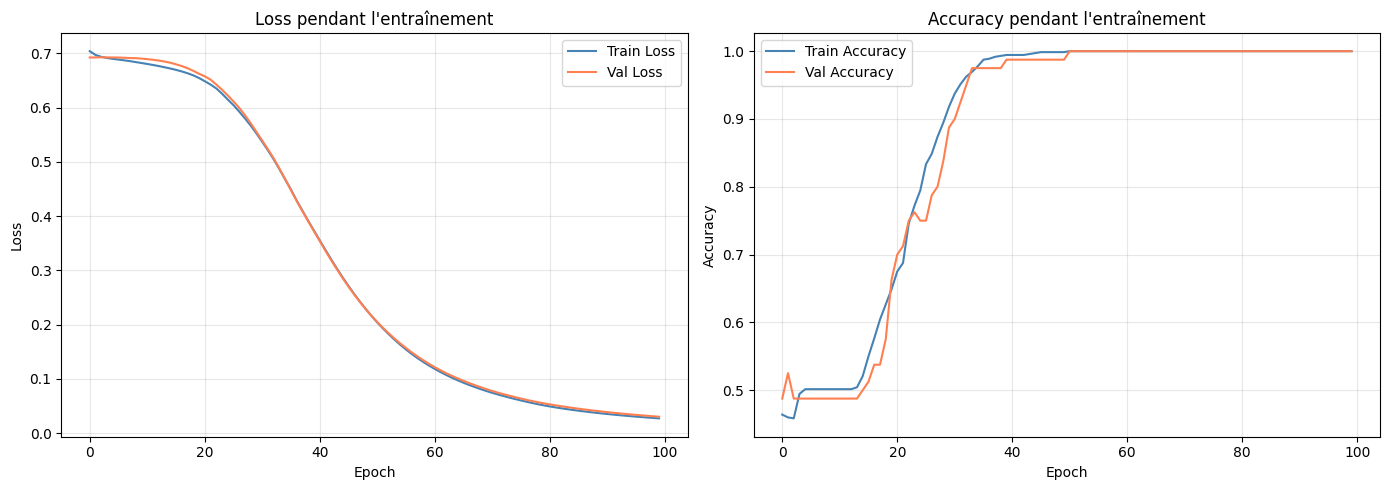


RÉSUMÉ COMPARATIF
Modèle basique   (SGD,  1 couche)  : 48.50%
Modèle amélioré  (Adam, 3 couches) : 100.00%
Gain de précision : +51.50%

CE QU'ON A APPRIS :

1. make_circles crée un problème non-linéaire
   → Une simple droite ne peut PAS séparer les classes
   → Il faut plusieurs couches avec ReLU

2. SGD vs Adam :
   → Adam converge beaucoup plus vite et mieux

3. Plus de couches + ReLU = le réseau peut apprendre
   des frontières circulaires complexes

4. La Decision Boundary montre visuellement
   comment le modèle sépare les classes

5. Toujours comparer train et validation
   pour détecter l'overfitting



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# ÉTAPE 1 — Comprendre les types de classification
# ============================================================
print("""
 TYPES DE CLASSIFICATION :

1. Binaire    → 2 classes (0 ou 1)
               Ex: Spam/Pas spam
               Loss: binary_crossentropy
               Activation sortie: sigmoid

2. Multi-class → N classes, une seule vraie
               Ex: MNIST (0 à 9)
               Loss: categorical_crossentropy
               Activation sortie: softmax

3. Multi-label → N classes, plusieurs vraies
               Ex: Tags d'un article (sport ET politique)
               Loss: binary_crossentropy sur chaque label
               Activation sortie: sigmoid par neurone
""")

# ============================================================
# ÉTAPE 2 — Créer et visualiser le dataset
# ============================================================
samples = 1000
X, y = make_circles(samples, noise=0.03, random_state=42)

print(f"X shape : {X.shape}")   # (1000, 2)
print(f"y shape : {y.shape}")   # (1000,)
print(f"Classes : {np.unique(y)}")

# Visualiser
plt.figure(figsize=(7, 6))
plt.scatter(X[y==0, 0], X[y==0, 1],
            color='steelblue', s=20,
            label='Classe 0 (cercle intérieur)')
plt.scatter(X[y==1, 0], X[y==1, 1],
            color='coral', s=20,
            label='Classe 1 (cercle extérieur)')
plt.title('Dataset : make_circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# ÉTAPE 3 — Split Train / Test (80% / 20%)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain : {X_train.shape[0]} exemples")
print(f"Test  : {X_test.shape[0]} exemples")

# ============================================================
# ÉTAPE 4 — Fonction plot_decision_boundary
# ============================================================
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Créer une grille de points
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Prédire sur toute la grille
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0).reshape(xx.shape)

    # Tracer
    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, preds,
                 alpha=0.3,
                 cmap='RdBu',
                 levels=50)
    plt.scatter(X[y==0, 0], X[y==0, 1],
                color='steelblue', s=20,
                label='Classe 0')
    plt.scatter(X[y==1, 0], X[y==1, 1],
                color='coral', s=20,
                label='Classe 1')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# ============================================================
# ÉTAPE 5 — Modèle basique (1 couche)
# ============================================================
print("\n MODÈLE BASIQUE (1 couche)")
model_basic = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid',
                          input_shape=(2,))
])

model_basic.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_basic = model_basic.fit(
    X_train, y_train,
    epochs=50,
    verbose=0,
    validation_split=0.1
)

loss_b, acc_b = model_basic.evaluate(X_test, y_test, verbose=0)
print(f"Précision basique : {acc_b*100:.2f}%")
plot_decision_boundary(model_basic, X, y,
                       f"Modèle basique — Accuracy: {acc_b*100:.1f}%")

# ============================================================
# ÉTAPE 6 — Modèle amélioré (plus de couches + Adam + ReLU)
# ============================================================
print("\n MODÈLE AMÉLIORÉ")
model_improved = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu',
                          input_shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])

model_improved.compile(
    optimizer='adam',               # Adam au lieu de SGD
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_improved = model_improved.fit(
    X_train, y_train,
    epochs=100,
    verbose=0,
    validation_split=0.1
)

loss_i, acc_i = model_improved.evaluate(X_test, y_test, verbose=0)
print(f"Précision améliorée : {acc_i*100:.2f}%")
plot_decision_boundary(model_improved, X, y,
                       f"Modèle amélioré — Accuracy: {acc_i*100:.1f}%")

# ============================================================
# ÉTAPE 7 — Courbes d'apprentissage
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_improved.history['loss'],
             label='Train Loss', color='steelblue')
axes[0].plot(history_improved.history['val_loss'],
             label='Val Loss', color='coral')
axes[0].set_title('Loss pendant l\'entraînement')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_improved.history['accuracy'],
             label='Train Accuracy', color='steelblue')
axes[1].plot(history_improved.history['val_accuracy'],
             label='Val Accuracy', color='coral')
axes[1].set_title('Accuracy pendant l\'entraînement')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ÉTAPE 8 — Résumé comparatif
# ============================================================
print("\n" + "="*45)
print("RÉSUMÉ COMPARATIF")
print("="*45)
print(f"Modèle basique   (SGD,  1 couche)  : {acc_b*100:.2f}%")
print(f"Modèle amélioré  (Adam, 3 couches) : {acc_i*100:.2f}%")
print(f"Gain de précision : +{(acc_i-acc_b)*100:.2f}%")

# ============================================================
# ÉTAPE 9 — Résumé des apprentissages
# ============================================================
print("""
CE QU'ON A APPRIS :

1. make_circles crée un problème non-linéaire
   → Une simple droite ne peut PAS séparer les classes
   → Il faut plusieurs couches avec ReLU

2. SGD vs Adam :
   → Adam converge beaucoup plus vite et mieux

3. Plus de couches + ReLU = le réseau peut apprendre
   des frontières circulaires complexes

4. La Decision Boundary montre visuellement
   comment le modèle sépare les classes

5. Toujours comparer train et validation
   pour détecter l'overfitting
""")